# Strassen attention vs. standard attention on Match3 (own stack)

This notebook reproduces the paper's Match3 experiment comparing exactly two attention mechanisms:

- **`standard`** — regular softmax dot-product (2nd-order) attention (`models/attentions/standard.py`)
- **`strassen`** — the paper's Strassen attention (`models/attentions/strassen.py`), a 3-way bilinear attention built from three pairwise score matrices `X, Y, Z` combined via `opt_einsum` contractions

`third_order` and `triangular` attention (also present in `models/attentions/`) are intentionally left out.

**Match3 task**: given a sequence of integers `x_1..x_n` (mod `M`), label token `i` as `1` if there exist `j, k` (possibly equal to `i`, possibly equal to each other) such that `x_i + x_j + x_k ≡ 0 (mod M)`. This is a 3rd-order relational predicate over triples of tokens.

**Unlike the other `match3_strassen_vs_standard` notebook in this repo**, this one does **not** clone or depend on the original `strassen-attention-neurips25` code at all. It uses this repo's own clean, independently-tested implementations:
- `datasets/generators/match3.py` + `datasets/torch_datasets/match3.py` — dataset generation/loading (JSON-Lines based)
- `models/attentions/standard.py`, `models/attentions/strassen.py` — the two attention mechanisms
- `models/embeddings/match3.py`, `models/tasks/match3.py` — the Match3-specific embedding, encoder layer, and classifier model built on top of them

**Hyperparameters are kept identical to the paper's own config** (`cmds/empirical/match3/hyperparams.json`, experiment `"33"`: `M=37`, `hidden_dim=128`, 1 layer, 2 heads, dropout=0.4, 45k/5k/5k/5k instances, 500 epochs, AdamW, lr=1e-3). The only changes are `BATCH_SIZE`, reduced from the paper's 2500 (sized for an A100) to fit a Colab GPU, and `DTYPE`, switched from the paper's `float64` to `float32` — adjust either up or down for your runtime.

**Note on `float32` vs `float64`**: the paper's models default to `float64` (needed for the numerical precision their theoretical constructions rely on). This notebook defaults to `float32` instead to keep VRAM usage down and throughput up on low-VRAM GPUs (most Colab GPUs — T4/P100 — also have much lower `float64` throughput than `float32`). If you hit numerical instability, switch `DTYPE` back to `torch.float64` in the config cell at the cost of roughly double the VRAM.

**Before running this on Colab**: commit and push any local changes to `datasets/` and `models/` first — the clone cell below pulls this repo from GitHub, not from your local filesystem.


## 1. Setup

In [11]:

REPO_URL = "https://github.com/MMVahedi/Thesis.git"  # use a token-embedded URL here if the repo is private
REPO_DIR = "Thesis"

!git clone {REPO_URL}
%cd {REPO_DIR}


fatal: destination path 'Thesis' already exists and is not an empty directory.
/content/Thesis/Thesis


In [12]:
!pip install -q opt_einsum scikit-learn


In [13]:
!ls datasets/

generators  README.md  torch_datasets


In [14]:
import os, json, random, time, gc
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. On Colab: Runtime > Change runtime type > GPU. "
          "This task is slow on CPU, especially with float64.")


Device: cuda


## 2. Config

Copied directly from the paper's `cmds/empirical/match3/hyperparams.json` (experiment `"33"`). Only `BATCH_SIZE` is reduced from the paper's 2500. Set `NUM_EPOCHS` to a small number first (e.g. 20) to sanity-check everything runs and time it, then raise it towards the paper's 500.

In [15]:
SEEDS = [42, 23, 54, 96, 12, 48, 67, 33]
MASTER_SEED = 45   # seeds dataset generation, so train/val/test/test_above are reproducible
SEED_INDEX = 0     # which entry of SEEDS to train each model with

config = {
    # --- task / data (hyperparams.json "33") ---
    "M": 37,
    "MAX_LEN": {"train_val": 35, "test": 29, "test_above": 36},
    "MIN_LEN": {"train_val": 30, "test": 29, "test_above": 36},
    "DATASET_BINS": {"train_val": 4, "test": 4, "test_above": 4},
    "NUM_TRAIN": 45000,       # matches the paper's own oversampled train/val split
    "NUM_VAL": 5000,
    "NUM_TEST": 5000,
    "NUM_TEST_ABOVE": 5000,
    "SHUFFLE": True,
    "NUM_WORKERS": 2,

    # --- model (hyperparams.json "33") ---
    "HIDDEN_DIM": 128,
    "NUM_LAYERS": 1,
    "NUM_HEADS": 2,
    "DROPOUT_RATE": 0.4,
    "SHARE_LAYERS": False,
    "USE_NORM": False,
    "USE_ATTENTION_DROPOUT": False,

    # --- optimization (hyperparams.json "33") ---
    "LR": 5e-3,
    "WEIGHT_DECAY": 1e-1,
    "NUM_EPOCHS": 200,

    # --- only these two are changed from the paper ---
    "BATCH_SIZE": 4096,        # paper uses 2500 (sized for an A100)
    "DTYPE": torch.float32,   # paper defaults to float64; using float32 here for lower VRAM usage / higher throughput on low-VRAM GPUs

    "DEVICE": device,
    "SEEDS": SEEDS,
    "SEED_INDEX": SEED_INDEX,
    "MASTER_SEED": MASTER_SEED,
}
config["EMBEDDING_NORM_SCALAR"] = config["M"]

SAVE_EVERY = 5   # epochs between checkpoint saves, so a Colab disconnect doesn't lose everything
RESULTS_DIR = "results/match3_own_stack"

{k: (str(v) if k == "DTYPE" else v) for k, v in config.items()}


{'M': 37,
 'MAX_LEN': {'train_val': 35, 'test': 29, 'test_above': 36},
 'MIN_LEN': {'train_val': 30, 'test': 29, 'test_above': 36},
 'DATASET_BINS': {'train_val': 4, 'test': 4, 'test_above': 4},
 'NUM_TRAIN': 45000,
 'NUM_VAL': 5000,
 'NUM_TEST': 5000,
 'NUM_TEST_ABOVE': 5000,
 'SHUFFLE': True,
 'NUM_WORKERS': 2,
 'HIDDEN_DIM': 128,
 'NUM_LAYERS': 1,
 'NUM_HEADS': 2,
 'DROPOUT_RATE': 0.4,
 'SHARE_LAYERS': False,
 'USE_NORM': False,
 'USE_ATTENTION_DROPOUT': False,
 'LR': 0.005,
 'WEIGHT_DECAY': 0.1,
 'NUM_EPOCHS': 200,
 'BATCH_SIZE': 4096,
 'DTYPE': 'torch.float32',
 'DEVICE': 'cuda',
 'SEEDS': [42, 23, 54, 96, 12, 48, 67, 33],
 'SEED_INDEX': 0,
 'MASTER_SEED': 45,
 'EMBEDDING_NORM_SCALAR': 37}

## 3. Data

Builds train (45k) / val (5k) / test (5k, in-distribution length) / test_above (5k, longer sequences than seen in training — tests length generalization), using our own `Match3Generator` (see `datasets/README.md`).

In [16]:
from compgen.datasets.generators.match3 import Match3Config, Match3Generator
from compgen.datasets.torch_datasets.match3 import Match3Dataset, match3_collate_fn


random.seed(config["MASTER_SEED"])
np.random.seed(config["MASTER_SEED"])
torch.manual_seed(config["MASTER_SEED"])

def build_split(length_key: str, num_instances: int) -> Match3Dataset:
    gen_config = Match3Config(
        num_instances=num_instances,
        seq_len=config["MAX_LEN"][length_key],
        min_len=config["MIN_LEN"][length_key],
        M=config["M"],
        num_bins=config["DATASET_BINS"][length_key],
    )
    path = f"/tmp/match3_{length_key}_{num_instances}.jsonl"
    Match3Generator(gen_config).save(path)
    return Match3Dataset(path)

datasets = {
    "train": build_split("train_val", config["NUM_TRAIN"]),
    "val": build_split("train_val", config["NUM_VAL"]),
    "test": build_split("test", config["NUM_TEST"]),
    "test_above": build_split("test_above", config["NUM_TEST_ABOVE"]),
}
{name: len(ds) for name, ds in datasets.items()}


{'train': 45000, 'val': 5000, 'test': 5000, 'test_above': 5000}

In [17]:
dataloaders = {
    name: DataLoader(
        ds,
        batch_size=config["BATCH_SIZE"],
        shuffle=config["SHUFFLE"],
        collate_fn=match3_collate_fn,
        num_workers=config["NUM_WORKERS"],
    )
    for name, ds in datasets.items()
}


## 4. Training loop

`run_epoch` unifies train/eval into one function (with `optimizer=None` for eval), toggling `model.train()`/`model.eval()` correctly — the original repo's `src/training/train.py` calls `model.eval()` in `evaluate_model` but never switches back to `model.train()`, silently disabling dropout for the rest of training after the first validation pass. This version avoids that bug.

In [18]:
from compgen.models.tasks.match3 import Match3Model

def run_epoch(model, dataloader, criterion, device, dtype, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, accuracies, f1_scores = 0.0, [], []
    with torch.enable_grad() if is_train else torch.no_grad():
        for batch in dataloader:
            if is_train:
                optimizer.zero_grad()

            y_hat, _ = model(batch)
            target = batch["label"].view(-1, 1).to(dtype).to(device)
            y_hat = y_hat.reshape(len(target), -1).to(dtype).to(device)
            mask = target != -100

            loss = criterion(y_hat[mask], target[mask])
            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            preds = y_hat > 0.5
            accuracies.append((preds[mask] == target[mask]).float().mean().item())
            f1_scores.append(f1_score(
                target[mask].detach().cpu().numpy(),
                preds[mask].detach().cpu().numpy(),
                zero_division=0,
            ))

            # values needed (loss/acc/f1) are already pulled onto the CPU above,
            # so this batch's activations/logits/mask can be dropped from VRAM now
            del batch, y_hat, target, mask, preds, loss

    if device == "cuda":
        torch.cuda.empty_cache()

    return total_loss / len(dataloader), np.mean(accuracies), np.mean(f1_scores)


def run_attention_type(attention_type, config, dataloaders, results_dir=RESULTS_DIR):
    seed = config["SEEDS"][config["SEED_INDEX"]]
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = Match3Model(
        hidden_dim=config["HIDDEN_DIM"],
        attention_type=attention_type,
        num_layers=config["NUM_LAYERS"],
        num_heads=config["NUM_HEADS"],
        dropout_rate=config["DROPOUT_RATE"],
        embedding_norm_scalar=config["EMBEDDING_NORM_SCALAR"],
        use_norm=config["USE_NORM"],
        use_attention_dropout=config["USE_ATTENTION_DROPOUT"],
        share_layers=config["SHARE_LAYERS"],
        dtype=config["DTYPE"],
        device=config["DEVICE"],
    ).to(config["DEVICE"])

    optimizer = torch.optim.AdamW(model.parameters(), lr=config["LR"], weight_decay=config["WEIGHT_DECAY"])
    criterion = torch.nn.BCELoss()

    history = {k: {"loss": [], "acc": [], "f1": []} for k in ["train", "val", "test", "test_above"]}
    os.makedirs(results_dir, exist_ok=True)
    history_path = os.path.join(results_dir, f"{attention_type}_history.json")

    num_epochs = config["NUM_EPOCHS"]
    for epoch in range(num_epochs):
        t0 = time.time()
        loss, acc, f1 = run_epoch(
            model, dataloaders["train"], criterion, config["DEVICE"], config["DTYPE"], optimizer=optimizer
        )
        history["train"]["loss"].append(loss)
        history["train"]["acc"].append(acc)
        history["train"]["f1"].append(f1)

        for subset in ["val", "test", "test_above"]:
            loss, acc, f1 = run_epoch(model, dataloaders[subset], criterion, config["DEVICE"], config["DTYPE"])
            history[subset]["loss"].append(loss)
            history[subset]["acc"].append(acc)
            history[subset]["f1"].append(f1)

        if epoch % SAVE_EVERY == 0 or epoch == num_epochs - 1:
            with open(history_path, "w") as f:
                json.dump(history, f)

        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(
                f"[{attention_type}] epoch {epoch + 1}/{num_epochs} "
                f"({time.time() - t0:.1f}s) "
                f"train_acc={history['train']['acc'][-1]:.3f} "
                f"val_acc={history['val']['acc'][-1]:.3f} "
                f"test_acc={history['test']['acc'][-1]:.3f} "
                f"test_above_acc={history['test_above']['acc'][-1]:.3f}"
            )

    return history, model


### Quick timing check (optional but recommended)

Runs 1 epoch of `strassen` (the more expensive attention) to estimate total runtime before committing to the full `NUM_EPOCHS`.

In [19]:
_probe_config = dict(config)
_probe_config["NUM_EPOCHS"] = 1
_t0 = time.time()
_probe_history, _probe_model = run_attention_type(
    "strassen", _probe_config, dataloaders, results_dir=f"{RESULTS_DIR}/_probe"
)
_epoch_time = time.time() - _t0
print(f"~{_epoch_time:.1f}s/epoch -> ~{_epoch_time * config['NUM_EPOCHS'] / 60:.1f} min for "
      f"{config['NUM_EPOCHS']} epochs (strassen only; standard is cheaper)")

# this probe model/history are only needed for the timing estimate above -
# drop them and reclaim their VRAM before the real training runs
del _probe_model, _probe_history, _probe_config
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()


[strassen] epoch 1/1 (8.3s) train_acc=0.500 val_acc=0.480 test_acc=0.490 test_above_acc=0.486
~8.3s/epoch -> ~27.7 min for 200 epochs (strassen only; standard is cheaper)


## 5. Train both attention types

`strassen` = Strassen attention from the paper. This is the main comparison.

In [ ]:
histories = {}
for attention_type in ["standard", "strassen"]:
    print(f"\n=== Training attention_type={attention_type} ===")
    histories[attention_type], _model = run_attention_type(attention_type, config, dataloaders)

    # the trained model is only consulted through `histories` from here on -
    # release it (and its optimizer state) from VRAM before the next attention type trains
    del _model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()



=== Training attention_type=standard ===
[standard] epoch 1/200 (3.4s) train_acc=0.499 val_acc=0.491 test_acc=0.481 test_above_acc=0.496
[standard] epoch 6/200 (3.5s) train_acc=0.510 val_acc=0.515 test_acc=0.519 test_above_acc=0.510
[standard] epoch 11/200 (3.7s) train_acc=0.513 val_acc=0.512 test_acc=0.516 test_above_acc=0.505
[standard] epoch 16/200 (3.4s) train_acc=0.514 val_acc=0.515 test_acc=0.525 test_above_acc=0.507
[standard] epoch 21/200 (4.6s) train_acc=0.535 val_acc=0.540 test_acc=0.554 test_above_acc=0.547
[standard] epoch 26/200 (3.5s) train_acc=0.582 val_acc=0.626 test_acc=0.604 test_above_acc=0.640
[standard] epoch 31/200 (3.8s) train_acc=0.633 val_acc=0.627 test_acc=0.629 test_above_acc=0.648
[standard] epoch 36/200 (3.4s) train_acc=0.651 val_acc=0.657 test_acc=0.654 test_above_acc=0.672
[standard] epoch 41/200 (3.4s) train_acc=0.663 val_acc=0.665 test_acc=0.658 test_above_acc=0.669
[standard] epoch 46/200 (3.9s) train_acc=0.673 val_acc=0.674 test_acc=0.671 test_above_

## 6. Compare

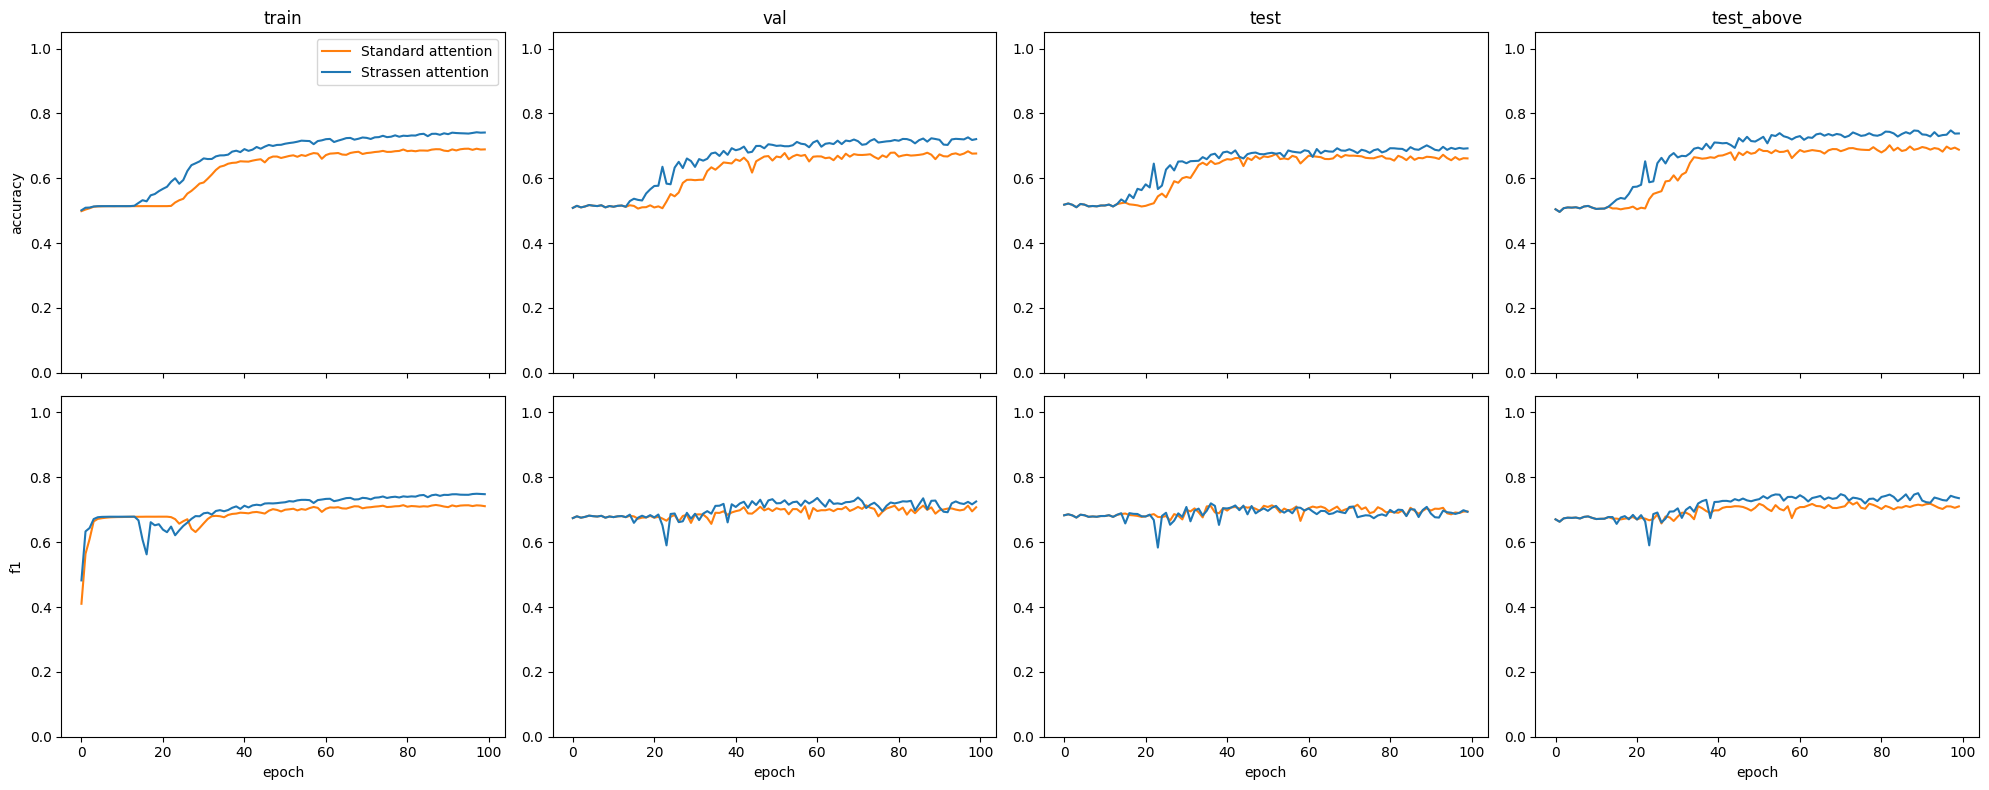

In [ ]:
import matplotlib.pyplot as plt

labels = {"standard": "Standard attention", "strassen": "Strassen attention"}
colors = {"standard": "tab:orange", "strassen": "tab:blue"}
subsets = ["train", "val", "test", "test_above"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True)
for col, subset in enumerate(subsets):
    for attention_type, history in histories.items():
        axes[0, col].plot(history[subset]["acc"], label=labels[attention_type], color=colors[attention_type])
        axes[1, col].plot(history[subset]["f1"], label=labels[attention_type], color=colors[attention_type])
    axes[0, col].set_title(subset)
    axes[0, col].set_ylim(0, 1.05)
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].set_xlabel("epoch")
axes[0, 0].set_ylabel("accuracy")
axes[1, 0].set_ylabel("f1")
axes[0, 0].legend()
plt.tight_layout()
os.makedirs(RESULTS_DIR, exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, "standard_vs_strassen.png"), dpi=150)
plt.show()


In [ ]:
import pandas as pd

rows = []
for attention_type, history in histories.items():
    row = {"attention": labels[attention_type]}
    for subset in subsets:
        row[f"{subset}_acc"] = history[subset]["acc"][-1]
        row[f"{subset}_f1"] = history[subset]["f1"][-1]
    rows.append(row)
pd.DataFrame(rows)


,attention,train_acc,train_f1,val_acc,val_f1,test_acc,test_f1,test_above_acc,test_above_f1
0,Standard attention,0.689004,0.711040,0.676305,0.707695,0.661181,0.694726,0.687996,0.710385
1,Strassen attention,0.740999,0.748053,0.720674,0.725505,0.692188,0.693765,0.738144,0.735742


## 7. (Optional) Download results

In [ ]:
!zip -rq match3_own_stack_results.zip {RESULTS_DIR}

try:
    from google.colab import files
    files.download("match3_own_stack_results.zip")
except ImportError:
    print("Not on Colab — find match3_own_stack_results.zip in the working directory.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

: 